Principios de Machine Learning - (PML) Proyecto Tarea de Clasificacion: arboles de decision y K-vecinos mas cercanos

Diego Burbano



### Importar las librerias necesarias para el modelo

In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
from google.colab import drive

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, KFold, GridSearchCV, validation_curve
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.neighbors import KNeighborsClassifier

from importlib.metadata import version

print(f"Versión de Pandas: {version('pandas')}")
print(f"Versión de Matplotlib: {version('matplotlib')}")
print(f"Versión de Scikit-learn: {version('scikit-learn')}")
print(f"Versión de Numpy: {version('numpy')}")

Versión de Pandas: 2.2.2
Versión de Matplotlib: 3.10.0
Versión de Scikit-learn: 1.6.1
Versión de Numpy: 1.26.4


##**1. Exploración y perfilamiento de los datos**

En esta sección se cargan al ambiente Colabs los datos alamcenados en la carpeta Drive de Google Drive

In [57]:
# En esta celda se esta montando el drive  que tiene almacenado los datos en la ruta MyDrive/datos.
drive.mount('/content/drive', force_remount=True)

# una vez se montó el drive, se cambia la ruta de archivo de 'content' de Colab por la ruta de Google Drive ('/MyDrive/datos/')
os.chdir('/content/drive/MyDrive/datos/')

Mounted at /content/drive


Se almacenan los datos en la variable *datos_crudos*:

In [58]:
datos_crudos = pd.read_csv('./Datos_Etapa-2.csv', sep=';', na_values=['?'], encoding = 'utf-8')


Se revisan los primeros datos del conjunto:

In [59]:
datos_crudos.head()

,pH,Dureza,Sólidos,Cloraminas,Sulfatos,Conductividad,Carbono_orgánico,Trihalometanos,Turbidez,Potabilidad
0,NaN,204.89,20791.32,7.30,368.52,564.31,10.38,86.99,2.96,NO
1,3.72,129.42,18630.06,6.64,NaN,592.89,15.18,56.33,4.50,NO
2,8.10,224.24,19909.54,9.28,NaN,418.61,16.87,66.42,3.06,NO
3,8.32,214.37,22018.42,8.06,356.89,363.27,18.44,100.34,4.63,NO
4,9.09,181.10,17978.99,6.55,310.14,398.41,11.56,32.00,4.08,NO


Nuestro conjunto trae una (1) variable categórica: *Potabilidad*. Las variables restantes son de tipo numérico.

In [60]:
datos_crudos.shape

(3276, 10)

Se exploran las variables numéricas:

In [61]:
variables_cat = ['Potabilidad']
variables_num = list(set(datos_crudos.columns) - set(variables_cat))

datos_crudos_cat = datos_crudos[variables_cat]
datos_crudos_num = datos_crudos[variables_num]

datos_crudos_num.describe()

,Dureza,Turbidez,Sulfatos,pH,Trihalometanos,Carbono_orgánico,Conductividad,Cloraminas,Sólidos
count,3276.000000,3276.000000,2495.000000,2785.000000,3114.000000,3276.000000,3276.000000,3276.000000,3276.000000
mean,196.369481,3.966731,333.775784,7.080804,66.396281,14.284921,426.205171,7.122241,22014.092415
std,32.879680,0.780354,41.416864,1.594369,16.174983,3.308232,80.824123,1.583143,8768.570852
min,47.430000,1.450000,129.000000,0.000000,0.740000,2.200000,181.480000,0.350000,320.940000
25%,176.847500,3.440000,307.695000,6.090000,55.847500,12.070000,365.735000,6.130000,15666.687500
50%,196.965000,3.955000,333.070000,7.040000,66.620000,14.220000,421.885000,7.130000,20927.830000
75%,216.670000,4.500000,359.950000,8.060000,77.337500,16.560000,481.790000,8.112500,27332.760000
max,323.120000,6.740000,481.030000,14.000000,124.000000,28.300000,753.340000,13.130000,61227.200000


En esta primera revisión de los datos numéricos encontramos las siguientes novedades confrontando los valores encontrados vs. la información contenida en el diccionario de datos:

1. pH: Encontramos que existen valores fuera del rango válido 6.5 a 8.5 y del rango de la investigación, ya que el mínimo muestra un valor de 0 y el valor máximo es de 14. Del total de datos del arreglo (3276) encontramos que el conteo de valores es de 2785, indicando una cantidad considerable de instancias sin valor en esta variable: 491.
2. Trihalometanos: Se encuentran 3114 valores de un total de 3276 de valores en el arreglo. Indicando 162 instancias sin valores en este campo.
3. Sulfatos: Se encuentran 2495 valores de un total de 3276 de valores en el arreglo. Indicando 781 instancias sin valores en este campo.

Como complemento al análisis presentado, se verifica si existen datos nulos:

In [62]:
datos_crudos_num.isna().sum()

,0
Dureza,0
Turbidez,0
Sulfatos,781
pH,491
Trihalometanos,162
Carbono_orgánico,0
Conductividad,0
Cloraminas,0
Sólidos,0


Comprobando de esta manera los resultados encontrados mediante la descripción inicial de los datos crudos obtenidos en el paso anterior. En la etapa de Limpieza y Preparación, alistaremos los datos descartando estos registros.

A continuación se explorará la variable categórica identificada: *Potabilidad*

In [63]:
datos_crudos_cat[['Potabilidad']].apply(pd.value_counts)

<ipython-input-63-450292167fdd>:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  datos_crudos_cat[['Potabilidad']].apply(pd.value_counts)


,Potabilidad
Potabilidad,
NO,1998
SI,1278


Se observa que la suma de la frecuencia de aparición de los valores corresponde al total de las instancias del arreglo, es decir 3276, indicando que no hay valores en blanco.

Finalmente se revisa si existen datos repetidos en el conjunto de datos suministrado:

In [64]:
datos_crudos.duplicated().sum()

0

No existen datos duplicados en el arreglo suministrado.

##**2. Limpieza y preparación de los datos**

Se define la variable datos para obtener una copia de los datos crudos:

In [65]:
datos = datos_crudos.copy()

Se revisa la cantidad de instancias en el dataset antes de la limpieza

In [66]:
datos.shape

(3276, 10)

Se eliminan las instancias con valores vacios en los campos identificados: pH, Trihalometanos y Sulfatos

In [67]:
datos = datos_crudos.dropna()
datos.shape

(2011, 10)

El dataframe quedó con un total de 2011 instancias, por lo tanto se eliminaron 1265 registros. Este volumen de datos representa el 38% del total de datos contenidos en el dataframe crudo. Se revisará mas adelante la importancia de las variables en el modelo para analizar si se reconsidera esta decisión.

In [68]:
datos.isna().sum()

,0
pH,0
Dureza,0
Sólidos,0
Cloraminas,0
Sulfatos,0
Conductividad,0
Carbono_orgánico,0
Trihalometanos,0
Turbidez,0
Potabilidad,0


###**División de datos**

Se divide el set de datos en un conjunto de entrenamiento (train) y prueba (test) en una proporción de 80% / 20%.

In [69]:
train, test = train_test_split(datos, test_size=0.2, random_state=77)
train.head()

,pH,Dureza,Sólidos,Cloraminas,Sulfatos,Conductividad,Carbono_orgánico,Trihalometanos,Turbidez,Potabilidad
530,6.64,198.88,27867.49,7.33,318.41,573.72,13.19,81.55,4.69,NO
2475,4.99,141.62,44499.73,8.26,335.51,534.71,15.35,62.90,3.93,NO
3146,8.30,183.61,20316.43,7.11,322.10,295.65,13.50,62.23,4.24,SI
1183,7.06,188.39,20567.15,7.44,360.32,656.92,16.27,84.83,4.40,SI
407,8.20,214.52,10389.54,6.30,327.19,403.19,15.07,72.76,3.22,SI


Se separa la variable objetivo, *Potabilidad* del set de datos.

In [70]:
x_train = train.drop(['Potabilidad'], axis = "columns")
y_train = train['Potabilidad']
#y_train = pd.DataFrame(train['Potabilidad'])

### **Transformación de variables categóricas**

Para este caso la variable categórica es precisamente la variable objetivo, la cual como se vio anteriormente cuenta con valores "SI" o "NO". Para poder entrenar el modelo se convertirá a valores numéricos (1 y 0) usando un label encoder.

In [71]:
y_train_df = y_train.to_frame()

y_train_df['Potabilidad'] = y_train_df['Potabilidad'].map({"NO": 0, "SI": 1})
y_train_df[['Potabilidad']].apply(pd.value_counts)

y_train = y_train_df.squeeze()

#encoder = OneHotEncoder(sparse_output=False,drop="if_binary").set_output(transform = "pandas")
#y_train_encoded = encoder.fit_transform(y_train)
#y_train['Potabilidad'] = y_train_encoded

<ipython-input-71-4d832946bb0b>:4: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  y_train_df[['Potabilidad']].apply(pd.value_counts)


In [72]:
y_train

,Potabilidad
530,0
2475,0
3146,1
1183,1
407,1
...,...
378,1
3264,1
2639,0
981,0


In [73]:
y_train_frec = y_train.value_counts().reset_index()
y_train_frec.columns = ['Potabilidad', 'Frecuencia']
print(y_train_frec)

   Potabilidad  Frecuencia
0            0         938
1            1         670


##**3. Construcción de un modelo de árboles de decisión**

Se crea un objeto de la clase *DecisionTreeClassifier()*

In [74]:
decision_tree = DecisionTreeClassifier(random_state=0)

Se utilizan los siguientes parámetros para realizar la búsqueda:
*   criterion: Entropia y Gini
*   maxdepth: [4,6,8,10,12]
*   min_samples_split: [3,4,5]
*   class_weight: 'balanced'



In [75]:
param_grid = {'criterion': ['entropy', 'gini'],
              'max_depth': [4, 6, 8, 10, 12],
              'min_samples_split': [3, 4, 5],
              'class_weight': ['balanced']}

Se define un objeto de la clase KFold() para realizar validación cruzada, especificando 10 subconjuntos. Posteriormente se define la búsqueda con el objeto grid de la clase GridSearchCV() usando para este caso el modelo decision_tree y se ejecutará la búsqueda sobre el subconjunto de entrenamiento.

In [76]:
kfold = KFold(n_splits=10, shuffle=True, random_state=0)

In [77]:
grid = GridSearchCV(decision_tree, param_grid, cv=kfold, n_jobs=-1)

In [78]:
grid.fit(x_train, y_train)

GridSearchCV(cv=KFold(n_splits=10, random_state=0, shuffle=True),
             estimator=DecisionTreeClassifier(random_state=0), n_jobs=-1,
             param_grid={'class_weight': ['balanced'],
                         'criterion': ['entropy', 'gini'],
                         'max_depth': [4, 6, 8, 10, 12],
                         'min_samples_split': [3, 4, 5]})

Se obtienen los mejores hiperparámetros para el modelo:

In [79]:
print("Mejores parámetros: {}".format(grid.best_params_))

Mejores parámetros: {'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': 8, 'min_samples_split': 3}


In [80]:
mejor_modelo = grid.best_estimator_

Y finalmente se obtiene la clasificación por importancia de las variables utilizadas en el modelo:

In [81]:
importancia = mejor_modelo.feature_importances_
importancia_df = pd.DataFrame(data={'Variable':x_train.columns, 'Importancia':importancia})
importancia_df.sort_values('Importancia', ascending=False)

,Variable,Importancia
0,pH,0.247937
4,Sulfatos,0.177332
2,Sólidos,0.169892
1,Dureza,0.130305
3,Cloraminas,0.105764
6,Carbono_orgánico,0.059330
5,Conductividad,0.057144
8,Turbidez,0.039510
7,Trihalometanos,0.012786


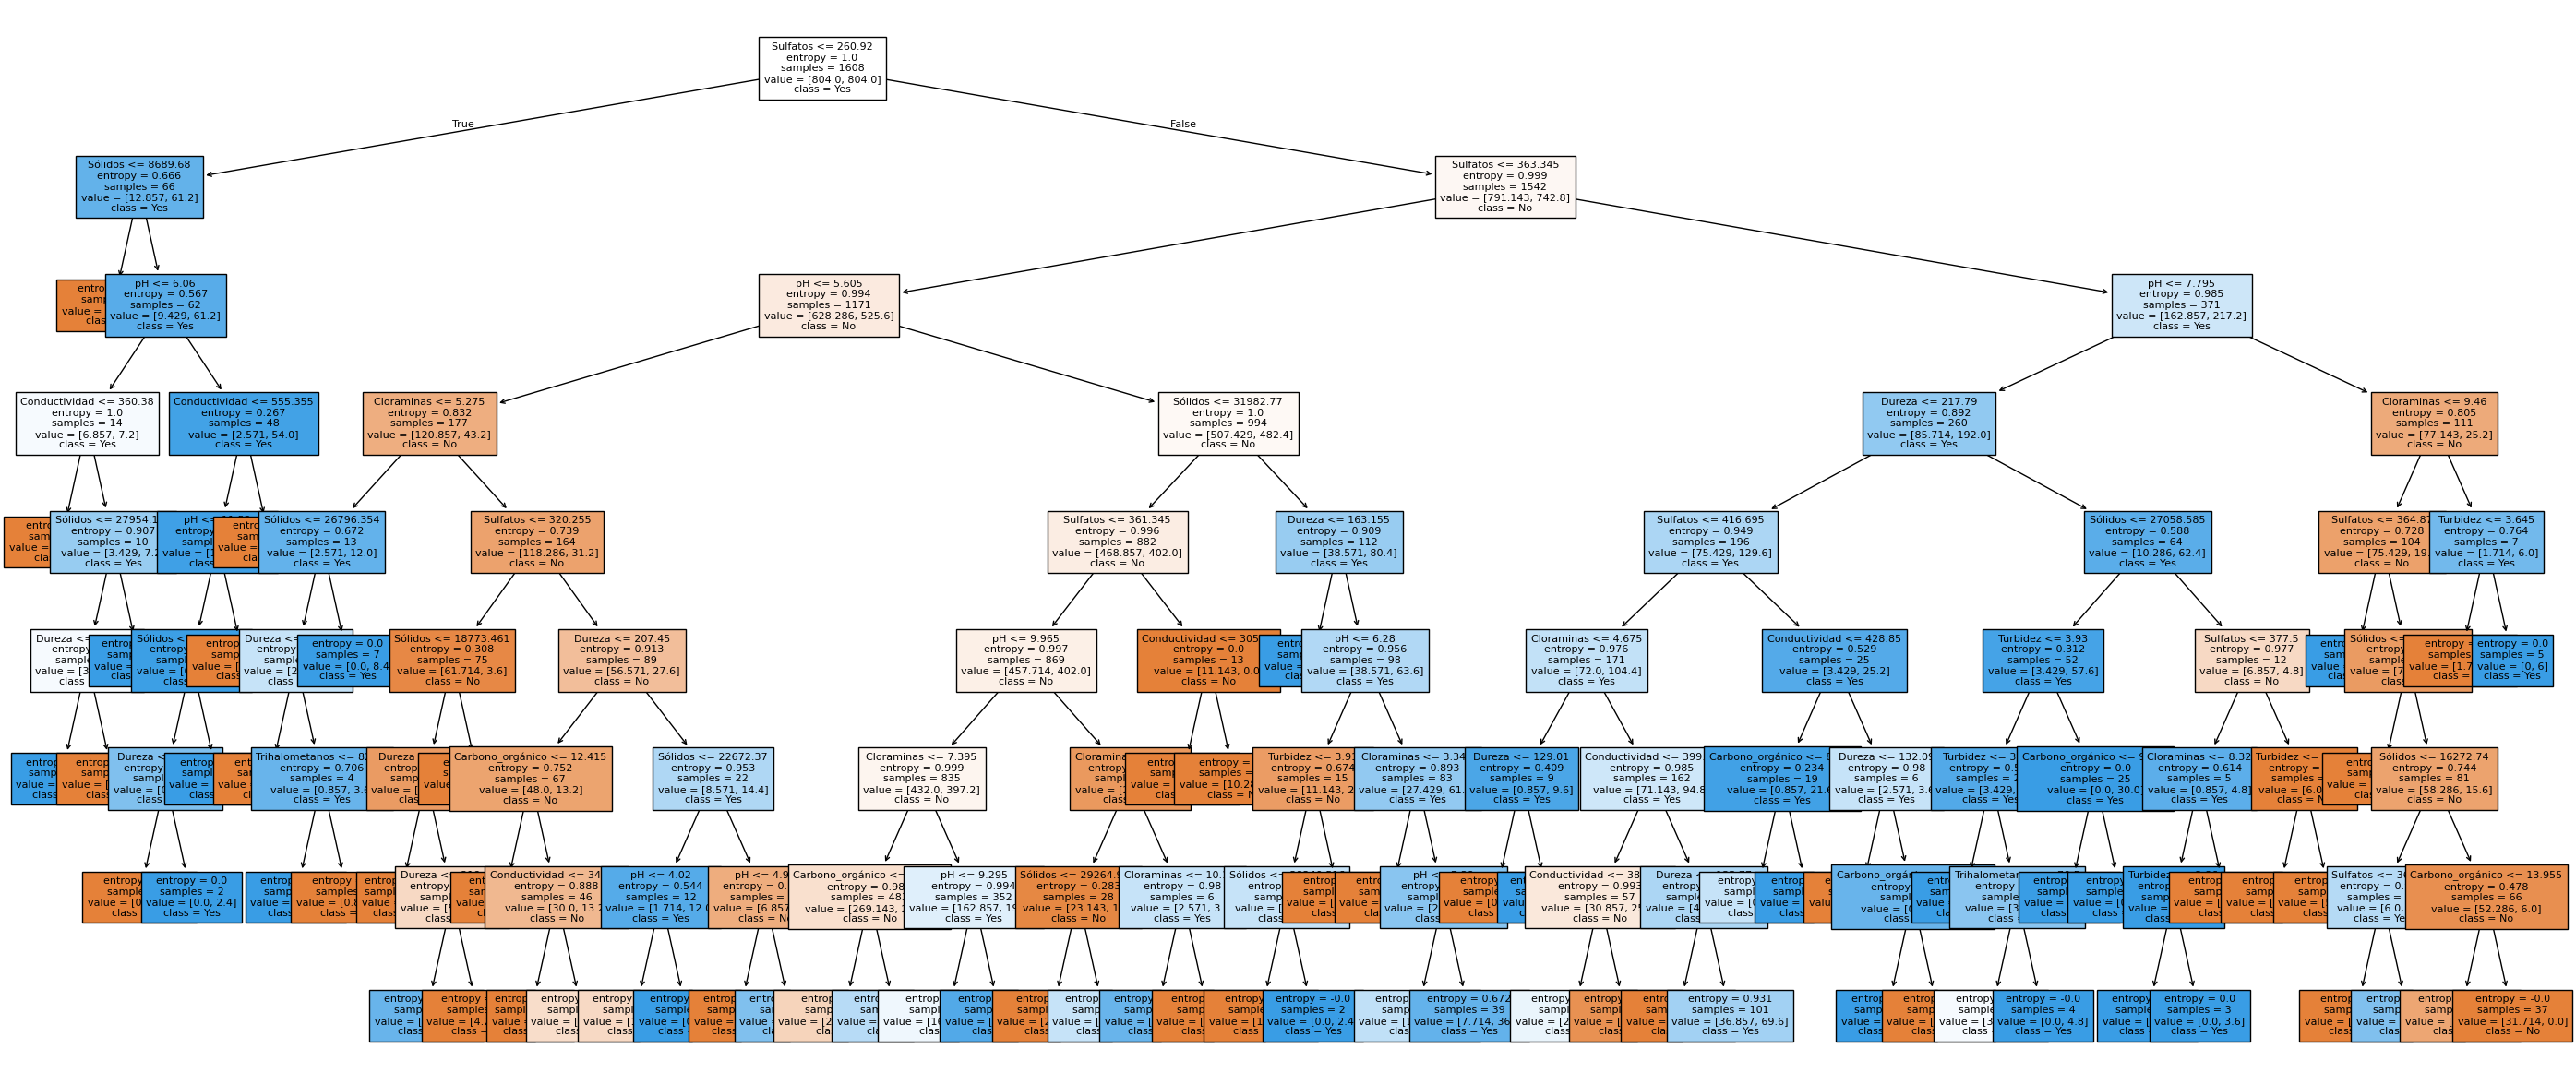

In [82]:
plt.figure(figsize=(35,15))
tree = plot_tree(mejor_modelo, feature_names=x_train.columns, class_names=['No','Yes'], filled=True, fontsize=8)

###**Evaluación del mejor modelo**

In [83]:
x_test = test.drop(['Potabilidad'],axis=1)
y_test = pd.DataFrame(test['Potabilidad'])
y_test['Potabilidad'] = y_test['Potabilidad'].map({"NO": 0, "SI": 1})
y_test[['Potabilidad']].apply(pd.value_counts)

<ipython-input-83-a26074a05329>:4: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  y_test[['Potabilidad']].apply(pd.value_counts)


,Potabilidad
Potabilidad,
0,262
1,141


In [84]:
y_pred = mejor_modelo.predict(x_test)

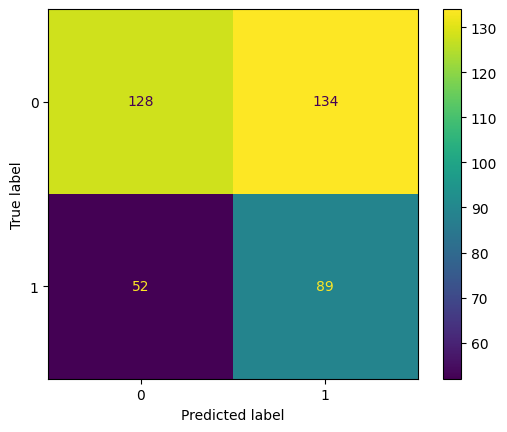

In [85]:
ConfusionMatrixDisplay.from_estimator(mejor_modelo, x_test, y_test)
plt.show()


In [86]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.71      0.49      0.58       262
           1       0.40      0.63      0.49       141

    accuracy                           0.54       403
   macro avg       0.56      0.56      0.53       403
weighted avg       0.60      0.54      0.55       403



Se almacenan los resultados del modelo (exactitud, recall, precisión y F1) en la variable *report_modelo_1* para que las mismas puedan ser comparadas en la etapa de Análisis Comparativo.

In [87]:
report_modelo_1 = classification_report(y_test, y_pred, output_dict=True)

##**Ejemplo de clasificación con el mejor modelo**

In [88]:
x_clasif = x_test.iloc[25]
x_clasif

,2934
pH,6.66
Dureza,205.54
Sólidos,18844.04
Cloraminas,6.73
Sulfatos,363.40
Conductividad,555.90
Carbono_orgánico,8.01
Trihalometanos,66.93
Turbidez,3.87


In [89]:
y_clasif = mejor_modelo.predict_proba([x_clasif])
y_clasif

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([[0.34621578, 0.65378422]])

In [90]:
np.argmax(y_clasif[0])

1

##**4. Construcción de un modelo utilizando el algoritmo K-vecinos mas cercanos**

### **Estandarización**

Se estandarizan las variables para que la escala no tenga influencia sobre el resultado de la clasificación.

In [91]:
scaler = StandardScaler().set_output(transform = "pandas")
# columns = x_train.columns
x_train = scaler.fit_transform(x_train)
# x_train = pd.DataFrame(x_train, columns=columns)
x_train

,pH,Dureza,Sólidos,Cloraminas,Sulfatos,Conductividad,Carbono_orgánico,Trihalometanos,Turbidez
530,-0.286308,0.079568,0.689866,0.133461,-0.346818,1.842134,-0.347119,0.948041,0.911092
2475,-1.337777,-1.658806,2.610412,0.713844,0.061174,1.357273,0.309327,-0.216662,-0.084907
3146,0.771533,-0.384019,-0.182064,-0.003834,-0.258778,-1.614038,-0.252907,-0.258504,0.321356
1183,-0.018662,-0.238901,-0.153113,0.202108,0.653122,2.876239,0.588925,1.152879,0.531040
407,0.707807,0.554388,-1.328334,-0.509330,-0.137334,-0.277408,0.224232,0.399100,-1.015380
...,...,...,...,...,...,...,...,...,...
378,-0.624053,1.605427,2.696983,0.158423,0.138955,-1.373906,-0.936706,1.392065,-1.172643
3264,-0.764249,1.305781,-0.157787,-0.478126,0.198365,-0.272063,1.406444,-0.157334,0.517934
2639,0.701435,1.012510,-1.004087,-0.690309,0.026340,2.236759,0.160411,2.307591,-0.399433
981,1.071042,0.580193,-0.914958,0.270756,-0.242076,-0.702111,1.394287,-0.725010,-0.281486


###**Graficación de una curva de validación para el hiperparámetro K**

A continuación se prepara la variable *k_values* con los valores [1, 2, 3, 4, 5] para determinar el número de vecinos:

In [92]:
k_values= list(range(1,6,1))
k_values

[1, 2, 3, 4, 5]

Seguidamente se obtienen los valores de desempeño para graficar la curva de validación:

In [93]:
train_scores, val_scores = validation_curve(estimator=KNeighborsClassifier(),
                                            X = x_train,
                                            y = y_train,
                                            param_name = 'n_neighbors',
                                            param_range = k_values,
                                            scoring = 'accuracy',
                                            cv=10)

In [94]:
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

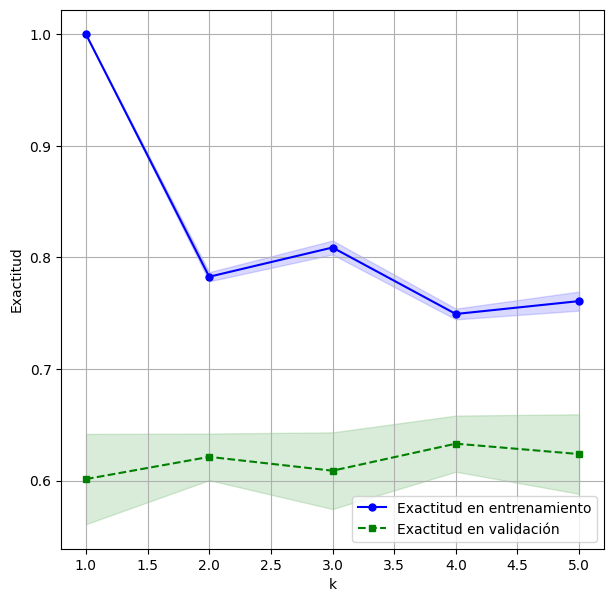

In [95]:
# Inicializamos la figura
plt.figure(figsize=(7,7))

# Creamos la curva de validación para el conjunto de entrenamiento
plt.plot(k_values, train_mean, color='blue', marker='o', markersize=5, label='Exactitud en entrenamiento')
plt.fill_between(k_values, train_mean+train_std, train_mean-train_std, alpha=0.15, color='blue')

# Creamos la curva de validación para el conjunto de validación
plt.plot(k_values, val_mean, color='green', linestyle='--', marker='s', markersize=5, label='Exactitud en validación')
plt.fill_between(k_values, val_mean+val_std, val_mean-val_std, alpha=0.15, color='green')

# Agregamos una grilla y etiquetas para los ejes
plt.grid()
plt.legend(loc='lower right')
plt.xlabel('k')
plt.ylabel('Exactitud')
plt.show()

Se obtendra el mejor valor de *k*, obteniendo el índice del mayor elemento:

In [96]:
mejor_indice = np.argmax(val_mean)
mejor_k = k_values[mejor_indice]
mejor_k

4

El mejor valor obtenido de *k* es 4.

Seguidamente se entrena el modelo de KNN con el mayor valor obtenido de *k*, almacenado en la variable *mejor_k*:

In [97]:
mejor_modelo = KNeighborsClassifier(n_neighbors=mejor_k).fit(x_train, y_train)

###**Evaluación del modelo**

Se realiza la estandarización de los datos del conjunto de pruebas.

In [98]:
x_test = scaler.transform(x_test)
x_test

,pH,Dureza,Sólidos,Cloraminas,Sulfatos,Conductividad,Carbono_orgánico,Trihalometanos,Turbidez
268,-0.139740,1.670700,-0.018973,1.050841,-1.268500,1.416436,-0.407902,-0.621967,0.963513
2651,1.077414,-0.143573,-0.014375,-1.476635,1.295651,0.124427,-0.745242,-0.645698,-0.215960
2197,1.517119,-0.821193,1.324708,0.838658,-0.405273,0.300920,-1.195030,0.497148,-1.094011
3057,0.573984,0.117517,-0.497687,-0.216018,-0.867904,-0.595718,-1.228460,0.032515,0.989723
840,-1.528953,0.140590,1.188098,0.907305,0.758818,1.135289,-0.587209,1.165369,-1.657537
...,...,...,...,...,...,...,...,...,...
1853,-1.981403,-1.075908,-0.861340,0.807454,-0.516457,-0.138947,1.956522,0.743203,-0.320802
706,-1.082875,-0.719793,0.716604,-0.827604,0.946590,0.994715,0.971852,0.056247,0.832460
498,-0.420132,-0.544316,0.473499,0.108498,-0.077448,1.755503,-0.717890,-0.351556,2.667196
2357,-0.917189,-0.255902,0.459052,-2.244239,0.121300,0.382207,0.354914,0.385986,1.133881


Se realizan las predicciones utilizando el conjunto de pruebas para comparar con los valores de *y_test*:

In [99]:
y_pred = mejor_modelo.predict(x_test)

A continuación se obtiene la matriz de confusión:

In [100]:
confusion_matrix(y_test, y_pred)

array([[226,  36],
       [104,  37]])

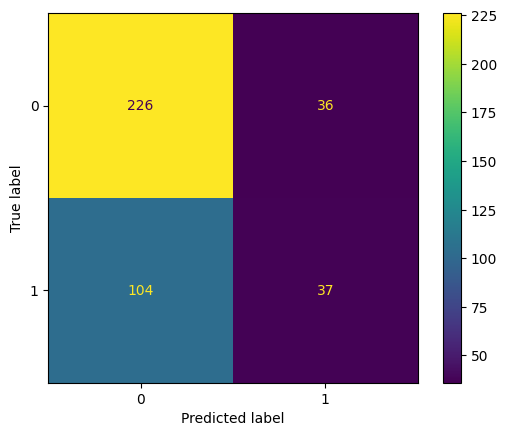

In [101]:
ConfusionMatrixDisplay.from_estimator(mejor_modelo, x_test, y_test)
plt.show()

In [102]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.68      0.86      0.76       262
           1       0.51      0.26      0.35       141

    accuracy                           0.65       403
   macro avg       0.60      0.56      0.55       403
weighted avg       0.62      0.65      0.62       403



Se almacenan los resultados del modelo (exactitud, recall, precisión y F1) en la variable *report_modelo_2* para que las mismas puedan ser comparadas en la etapa de Análisis Comparativo.

In [103]:
report_modelo_2 = classification_report(y_test, y_pred, output_dict=True)

###**5. Tabla Comparativa - Rendimiento de los modelos obtenidos**

Generamos la tabla comparativa con los resultados de los dos modelos:

In [104]:
datos_comparativos = {
    'Métrica': ['Precisión (Sí)', 'Recall (Sí)', 'F1-Score (Sí)',
                 'Precisión (No)', 'Recall (No)', 'F1-Score (No)',
                 'Exactitud'],
    'Arbol de Decisión': [
        report_modelo_1['1']['precision'],
        report_modelo_1['1']['recall'],
        report_modelo_1['1']['f1-score'],
        report_modelo_1['0']['precision'],
        report_modelo_1['0']['recall'],
        report_modelo_1['0']['f1-score'],
        report_modelo_1['accuracy']
    ],
    'K-vecinos': [
        report_modelo_2['1']['precision'],
        report_modelo_2['1']['recall'],
        report_modelo_2['1']['f1-score'],
        report_modelo_2['0']['precision'],
        report_modelo_2['0']['recall'],
        report_modelo_2['0']['f1-score'],
        report_modelo_2['accuracy']
    ]
}
tabla_comparativa = pd.DataFrame(datos_comparativos)
tabla_comparativa = tabla_comparativa.round(3)

# Se genera formato a la tabla

def resaltar_max_min(val):
    color = ''
    if val == tabla_comparativa['Arbol de Decisión'].max() or val == tabla_comparativa['K-vecinos'].max():
        color = 'background-color: lightgreen'
    elif val == tabla_comparativa['Arbol de Decisión'].min() or val == tabla_comparativa['K-vecinos'].min():
        color = 'background-color: lightcoral'
    return color

styled_table = tabla_comparativa.style.set_caption("Comparación de Métricas entre Modelos") \
    .set_table_styles([{'selector': 'caption',
                        'props': [('font-size', '16px'),
                                  ('font-weight', 'bold'),
                                  ('text-align', 'center')]}]) \
    .highlight_max(subset=['Arbol de Decisión', 'K-vecinos'], color='lightgreen', axis=1) \
    .highlight_min(subset=['Arbol de Decisión', 'K-vecinos'], color='lightcoral', axis=1) \
    .set_properties(**{'border': '1px solid black', 'text-align': 'center'}) \
    .format(precision=3)

styled_table


,Métrica,Arbol de Decisión,K-vecinos
0,Precisión (Sí),0.399,0.507
1,Recall (Sí),0.631,0.262
2,F1-Score (Sí),0.489,0.346
3,Precisión (No),0.711,0.685
4,Recall (No),0.489,0.863
5,F1-Score (No),0.579,0.764
6,Exactitud,0.538,0.653


### **6. Reglas para determinar cuando el agua no es potable**

### **7. Análisis de Resultados**

* *¿Qué puedes decir de los valores de las métricas recall y precisión para cada una de las clases en cada modelo? ¿Cuál de estás métricas consideras que es más importante con base en la descripción del problema?*

    Considerando que el modelo evalua la calidad de agua para consumo humano, es crítico que el modelo tenga la capacidad de predecir correctamente cuando el agua es potable con la mayor precisión posible; es decir, no sería aceptable que el modelo predijera que agua no apta para el consumo fuera predicha como potable. Por las razones anteriormente expuestas la métrica mas importante en el contexto del problema, es la precisión sobre la clase 1, es decir sobre la Potabilidad "SI".

    Teniendo en cuenta lo anteriormente expresado, el mejor modelo para el problema expuesto es K-vecinos. Adicionalmente, la exactitud de este modelo es superior a la del Árbol de decisión.


* *¿Consideras que el rendimiento de los modelos es adecuado? Si no es así, ¿Cómo podrían mejorarse los resultados?*

* *¿Cuáles son las variables más significativas según el mejor modelo basado en árboles de decisión? Reflexiona sobre cómo este nuevo conocimiento podría ayudar a tomar decisiones en el contexto del problema.*
    
    Las variables mas importantes, según el modelo de Árboles de decisión son las siguientes:
    - pH
    - Sulfatos
    - Sólidos
    
* *Si los dos modelos proporcionan resultados similares en cuanto a las métricas de rendimiento ¿Cuál seleccionarías tomando en cuenta el contexto del problema?*